In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
data = pd.read_csv('Employee_Salary_Dataset.csv')
data.head()

,Employee_ID,Age,Department,Education_Level,Years_of_Experience,Salary
0,E1000,30,Marketing,Bachelor's,7.5,63977.86
1,E1001,40,HR,Bachelor's,19.0,112242.00
2,E1002,36,IT,Bachelor's,14.6,106419.72
3,E1003,36,IT,Bachelor's,12.0,87169.60
4,E1004,26,Finance,Bachelor's,3.1,33824.29


In [17]:
print('Data Shape',data.shape)
print('====Info====')
data.info()
print('===describe data===')
data.describe()
data.isnull().sum()

Data Shape (300, 6)
====Info====
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          300 non-null    str    
 1   Age                  300 non-null    int64  
 2   Department           300 non-null    str    
 3   Education_Level      300 non-null    str    
 4   Years_of_Experience  300 non-null    float64
 5   Salary               300 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 14.2 KB
===describe data===


Employee_ID            0
Age                    0
Department             0
Education_Level        0
Years_of_Experience    0
Salary                 0
dtype: int64

In [18]:
X = data[['Years_of_Experience']]
Y = data['Salary']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 240
Testing samples: 60


In [21]:
model = LinearRegression()
model.fit(X_train, Y_train)

print(f"Slope: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Slope: 4538.39
Intercept: 29825.74


In [23]:
predicted_salaries = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual_Salary':Y_test.values,
    'Predicted_Salary':predicted_salaries.round(2)
})
comparison.head(10)

,Actual_Salary,Predicted_Salary
0,111370.47,111516.75
1,88171.91,92909.35
2,39254.34,42987.06
3,93326.32,94270.87
4,73445.15,74755.79
5,114981.75,118324.33
6,100542.12,95632.38
7,37968.44,36633.32
8,44882.27,43894.74
9,45038.10,45710.10


In [24]:
mae = mean_absolute_error(Y_test,predicted_salaries)

mse = mean_squared_error(Y_test,predicted_salaries)

rmse = np.sqrt(mse)

r2 = r2_score(Y_test, predicted_salaries)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R^2 Score (Model Accuracy): {r2:.2f}")

Mean Absolute Error (MAE): 3283.10
Mean Squared Error (MSE): 16688673.51
Root Mean Squared Error (RMSE): 4085.18
R^2 Score (Model Accuracy): 0.98


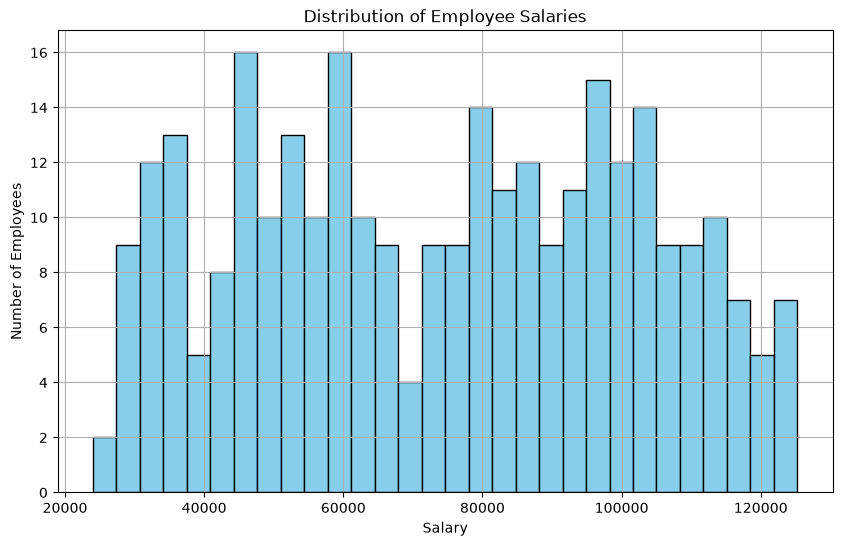

In [25]:
plt.figure(figsize=(10,6))
plt.hist(data['Salary'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Employee Salaries')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.show()

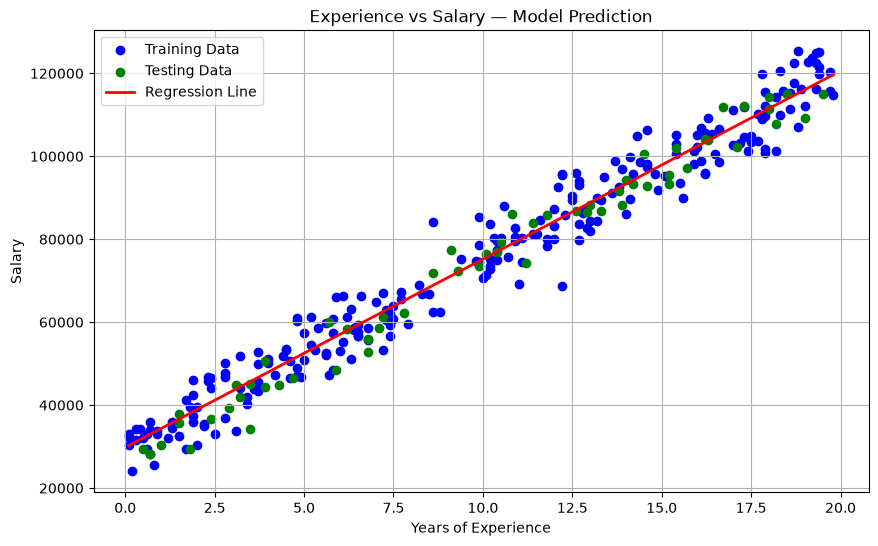

In [26]:
# Scatter plot: Actual data points + Regression line
plt.figure(figsize=(10,6))

# Training data ke actual points (blue)
plt.scatter(X_train, Y_train, color='blue', label='Training Data')

# Testing data ke actual points (green)
plt.scatter(X_test, Y_test, color='green', label='Testing Data')

# Regression line pura X range ke liye
X_line = pd.DataFrame({'Years_of_Experience': np.linspace(X['Years_of_Experience'].min(), X['Years_of_Experience'].max(), 100)})
plt.plot(X_line, model.predict(X_line), color='red', linewidth=2, label='Regression Line')

plt.title('Experience vs Salary — Model Prediction')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
# Maan lo ek naye employee ka experience 6.5 years hai
new_experience = 6.5

predicted_salary = model.predict(pd.DataFrame({'Years_of_Experience': [new_experience]}))

print(f"Predicted Salary for {new_experience} years experience: {predicted_salary[0]:.2f}")


Predicted Salary for 6.5 years experience: 59325.27
